In [1]:
import bioframe as bf
import pandas as pd
import numpy as np
import bbi
import matplotlib.pyplot as plt

In [2]:
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks
from matplotlib.ticker import FuncFormatter, FixedLocator

In [3]:
bigWig_control = bbi.open('/users/uladzis.khauratovich/groups_SLAVA/ATAC_Seq/Replicates_From_Date200722_results_3VS_3_FOR_FURTHER_ANALYSIS/results/bwa/mergedReplicate/bigwig/control.mRp.clN.bigWig')
bigWig_exp = bbi.open('/users/uladzis.khauratovich/groups_SLAVA/ATAC_Seq/Replicates_From_Date200722_results_3VS_3_FOR_FURTHER_ANALYSIS/results/bwa/mergedReplicate/bigwig/experimental.mRp.clN.bigWig')

In [4]:
# Get chromosome sizes
chrom_sizes = bigWig_exp.chromsizes

#chrom_sizes_XY = {key: value for key, value in chrom_sizes.items() if key in ('X', 'Y')}
chrom_sizes_X = {key: value for key, value in chrom_sizes.items() if key in ('X')}

# Define the bin size (2000 nucleotides)
bin_size = 2000

# Create an empty list to store bin coordinates
bin_coordinates = []

# Iterate over each chromosome
for chrom, chrom_size in chrom_sizes_X.items():
    # Generate bin coordinates for the current chromosome
    for start in range(0, chrom_size, bin_size):
        end = min(start + bin_size, chrom_size)
        bin_coordinates.append((chrom, start, end))

# Convert the list of coordinates to a NumPy array
bin_array = np.array(bin_coordinates)

df = pd.DataFrame(bin_array, columns=['chrom', 'start', 'end'])
df = df.astype({'chrom':'string', 'start':'int', 'end':'int'})

In [6]:
annot_gtf_tss = (
    pd.read_csv("/users/uladzis.khauratovich/groups_SLAVA/ATAC_Seq/ATAC_RNA_Seq/Mus_musculus_GTF_genes_short_GRCm38_95.csv")
    .assign(
        start=lambda df: np.where(df['strand'] == '+', df['start'], df['end']),
        end=lambda df: np.where(df['strand'] == '+', df['start'], df['end']) + 1,
        chrom=lambda df: df['chrom'].str.replace('chr', '', regex=True)
    )
    # Drop mitochondrial chromosome
    .query("chrom != 'MT'")
    # Sort by chromosome and position
    .sort_values(by=['chrom', 'start'])
    # Keep only relevant columns
    .loc[:, ['chrom', 'start', 'end']]
    .reset_index(drop=True)
)

In [7]:
df_notss = bf.setdiff(df, annot_gtf_tss)

In [8]:
df = df_notss
cov_ctr_chrX = bigWig_control_consensus.stackup(df["chrom"],
                                                df["start"],
                                                df["end"], 
                                                bins=1, summary='sum').flatten()
cov_exp_chrX = bigWig_exp_consensus.stackup(df["chrom"],
                                            df["start"],
                                            df["end"],
                                            bins=1, summary='sum').flatten()

In [9]:
df_notss['cov_control'] = cov_ctr_chrX.tolist()
df_notss['cov_exp'] = cov_exp_chrX.tolist()

In [10]:
df_notss['cov_change'] = df_notss['cov_exp'] / df_notss['cov_control']

In [11]:
df_notss.replace([np.inf, -np.inf], np.nan, inplace=True)
# Drop rows with NaN
df_notss.dropna(inplace=True)

df_notss_no0 = df_notss[
    df_notss['cov_change'] != 0].copy()

In [12]:
df_notss_no0

,chrom,start,end,cov_control,cov_exp,cov_change
1525,X,3050000,3052000,34.668151,66.631611,1.921983
1526,X,3052000,3054000,37.585814,85.224342,2.267460
1527,X,3054000,3056000,25.881999,53.060728,2.050102
1528,X,3056000,3058000,9.494560,44.871770,4.726051
1529,X,3058000,3060000,21.557066,50.571306,2.345927
...,...,...,...,...,...,...
85425,X,170850000,170852000,36.759698,102.574786,2.790414
85426,X,170852000,170854000,4.602745,33.593144,7.298502
85428,X,170856000,170858000,33.938786,124.304500,3.662609
85429,X,170858000,170860000,71.957338,259.623533,3.608020


In [33]:
print(np.median(df_notss_no0['cov_change']))
print(np.log10(np.median(df_notss_no0['cov_change'])))

2.2400466592938413
0.3502570646121981


In [26]:
# Get chromosome sizes
chrom_sizes = bigWig_exp_consensus.chromsizes

#chrom_sizes_XY = {key: value for key, value in chrom_sizes.items() if key in ('X', 'Y')}
chrom_sizes_Y = {key: value for key, value in chrom_sizes.items() if key in ('Y')}

# Define the bin size (2000 nucleotides)
bin_size = 2000

# Create an empty list to store bin coordinates
bin_coordinates = []

# Iterate over each chromosome
for chrom, chrom_size in chrom_sizes_Y.items():
    # Generate bin coordinates for the current chromosome
    for start in range(0, chrom_size, bin_size):
        end = min(start + bin_size, chrom_size)
        bin_coordinates.append((chrom, start, end))

# Convert the list of coordinates to a NumPy array
bin_array = np.array(bin_coordinates)

df_Y = pd.DataFrame(bin_array, columns=['chrom', 'start', 'end'])

# Display the first few rows of the array
# print

In [27]:
df_Y = df_Y.astype({'chrom':'string', 'start':'int', 'end':'int'})

In [30]:
df_Y_notss

,chrom,start,end
0,Y,0,2000
1,Y,2000,4000
2,Y,4000,6000
3,Y,6000,8000
4,Y,8000,10000
...,...,...,...
45868,Y,91736000,91738000
45869,Y,91738000,91740000
45870,Y,91740000,91742000
45871,Y,91742000,91744000


In [29]:
df_Y_notss = bf.setdiff(df_Y, annot_gtf_tss)

In [31]:
df_Y = df_Y_notss
cov_ctr_chrY = bigWig_control_consensus.stackup(df_Y["chrom"],
                                                df_Y["start"],
                                                df_Y["end"], 
                                                bins=1, summary='sum').flatten()
cov_exp_chrY = bigWig_exp_consensus.stackup(df_Y["chrom"],
                                            df_Y["start"],
                                            df_Y["end"],
                                            bins=1, summary='sum').flatten()

In [37]:
df_Y_notss['cov_control'] = cov_ctr_chrY.tolist()
df_Y_notss['cov_exp'] = cov_exp_chrY.tolist()

In [38]:
df_Y_notss['cov_change'] = df_Y_notss['cov_exp'] / df_Y_notss['cov_control']

In [39]:
df_Y_notss.replace([np.inf, -np.inf], np.nan, inplace=True)
# Drop rows with NaN
df_Y_notss.dropna(inplace=True)

df_Y_notss_no0 = df_Y_notss[
    df_Y_notss['cov_change'] != 0].copy()

In [44]:
print(np.median(df_Y_notss_no0['cov_change']))
print(np.log10(np.median(df_Y_notss_no0['cov_change'])))

1.7938034932243327
0.25377486541785527


In [43]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   # TrueType
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.size'] = 20 

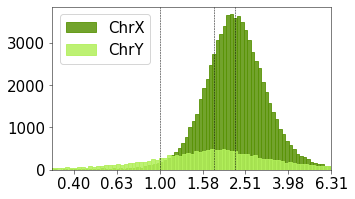

In [46]:
plt.figure(figsize=(5, 3))

# ── 1. log10-transform ─────────────────────────────────────────────────────────
data_log10_cov_change_Y = np.log10(df_Y_notss_no0['cov_change'])
data_log10_cov_change_X = np.log10(df_notss_no0['cov_change'])

# ── 2. histogram (counts on y-axis) ────────────────────────────────────────────
plt.hist(
    data_log10_cov_change_X,
    bins=300,                     # ~0.04-wide bins across your range
    color='#599307',
    alpha=0.85,
    edgecolor='#599307',
    label='ChrX',
    density=False                # <- the key switch from a KDE
)
plt.hist(
    data_log10_cov_change_Y,
    bins=300,                     # ~0.04-wide bins across your range
    color='#b2ef5b',
    alpha=0.85,
    edgecolor='#b2ef5b',
    label='ChrY',
    density=False                # <- the key switch from a KDE
)

# ── 3. vertical reference lines ────────────────────────────────────────────────
plt.axvline(0.0,   color='black', linestyle='dashed', linewidth=0.5)
plt.axvline(0.2538, color='black', linestyle='dashed', linewidth=0.5)
plt.axvline(0.3503, color='black', linestyle='dashed', linewidth=0.5)

# ── 4. x-axis: show the *linear* values even though we plot in log space ──────
def custom_tick_formatter(x, pos):
    return f'{10**x:.2f}'        # back-transform ticks

def custom_tick_locator():
    return FixedLocator(np.arange(-1, 1.4, 0.2))

ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(custom_tick_formatter))
ax.xaxis.set_major_locator(custom_tick_locator())

ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(custom_tick_formatter))
ax.xaxis.set_major_locator(custom_tick_locator())

# Make frame and tick lines thinner
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
ax.tick_params(width=0.5)
plt.legend(fontsize=15)

plt.xlim(-0.5, 0.8)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

#plt.show()

# plt.savefig("Histogram_chromatin_accessibility_Sex_chrom_2kb_300bins_mine_green_s1.pdf", dpi=300, bbox_inches="tight", pad_inches=1)